## THE INTENT IS TO EXPLORE THE TIMESTAMP DATA. THE TIMESTAMPS ARE JUST FLOAT NUMBERS AND NOT YY:MM:DD HH-MM-SS VALUES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [2]:
%%time
df2=pd.read_csv("sub_date.csv",nrows=40000)

CPU times: user 3.4 s, sys: 448 ms, total: 3.85 s
Wall time: 3.9 s


In [3]:
df2.drop(columns=['Unnamed: 0'], axis=1,inplace=True)

In [4]:
df2.set_index("Id",inplace=True)

### MANIPULATING COLUMN NAME BASED ON THE GIVEN RULE 

In [5]:
cols2=df2.columns.tolist()
cols2=[each.split("_")[0]+"_"+each.split("_")[1]+"_"+"F"+
       str(int(each.split("_")[2][1:])-1) for each in cols2]
df2.columns=cols2

In [6]:
df2.head()

,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,L0_S0_F18,...,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4254,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262
Id,,,,,,,,,,,,,,,,,,,,,
4,82.24,82.24,82.24,82.24,82.24,82.24,82.24,82.24,82.24,82.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1618.70,1618.70,1618.70,1618.70,1618.70,1618.70,1618.70,1618.70,1618.70,1618.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1149.20,1149.20,1149.20,1149.20,1149.20,1149.20,1149.20,1149.20,1149.20,1149.20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,602.64,602.64,602.64,602.64,602.64,602.64,602.64,602.64,602.64,602.64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### AS WE SEE THE NUMBERS, WE NEED TO CHECK IF THEY ARE INCREASING IN SEQUENCE OVER EACH ROW. IF THATS THE CASE, WE CAN ASSUME THAT EACH ROW OF DATAFRAME IS ONE PROCESSING ONE UNIQUE COMPONENT. WITH THIS WE CAN ALSO ASSUME THAT THE FLOAT NUMBERS DENOTE SOME [YY-MM-DD HH:MM:SS] TIMESTAMP VALUE THAT IS NOT KNOWN TO US.

### CHECKING THE SORT OF ROWS AND USING THE sortedrows LIST

In [7]:
%%time
sortedrows=[]
for each in df2.index:
    a=df2.loc[each].tolist()
    if(sorted(a)==a):
        #df2["sortedRows"].loc[each]="sorted"
        sortedrows.append("sorted")
    else:
        sortedrows.append("not sorted")

CPU times: user 5.65 s, sys: 13.2 ms, total: 5.66 s
Wall time: 5.68 s


### WE SEE THAT ALL THE ROWS ARE SORTED 

In [8]:
print(set(sortedrows))

{'sorted'}


### GET THE MINIMUM TIME VALUE OF EACH ROW. IT WILL HELP TO KEEP THE PROCESSING IN SEQUENCE

In [9]:
df2["min"]=df2.min(axis=1)

### GET THE MAXIMUM TIME VALUE OF EACH ROW. IT WILL HELP TO CALCULATE THE PROCESSING TIME FOR EACH COMPONENT DENOTED BY EACH ROW 

In [10]:
df2["max"]=df2.max(axis=1)

### DELETE THE ROWS WILL ALL NULL VALUES

In [11]:
df2=df2[df2["min"]>0]

### STORE THE MAX/MIN TIME AS LIST AS THE DATAFRAME WILL NOW BE PROCESSED HEAVILY

In [12]:
tMin=df2["min"].tolist()
tMax=df2["max"].tolist()

### FILL ALL THE NULL VALUES AS 0 AND ALL NONZERO VALUES AS 1. WE ARE DOING THIS BECAUSE THEN FOR EACH ROW WE CAN GET A SEQUENCE OF STRING THAT HAS ONLY 0 AND 1. WE CAN USE THIS SEQUENCE TO REPRESENT PRODUCTS.

In [13]:
df2=df2.fillna(0)

In [14]:
df2[df2!=0]=1

In [15]:
df2=df2.astype('int')

### NOW WITH ALL THE 0 AND 1 VALUES, WE ARE UPDATING THE DATAFRAME WITH REAL MIN, MAX, AND PROCESSING TIME VALUES.

In [16]:
df2["min"]=tMin
df2["max"]=tMax
df2["timetaken"]=df2["max"]-df2["min"]

In [17]:
df2=df2.sort_values(by="min")

df2

### SINCE THE SEUQNCE OF 0 AND 1 WILL BE VERY LONG. IT WILL BE STORED AS A LIST AND THEN MAKE IT A COLUMN IN THE DATAFRAME.

In [18]:
%%time
properties=[]
for each in df2.index:
    a=df2.loc[each].tolist()[:-3]
    strings=[str(int(each)) for each in a]
    a_string = "".join(strings)
    properties.append(a_string)

CPU times: user 38.2 s, sys: 90.3 ms, total: 38.3 s
Wall time: 38.3 s


In [19]:
df2["products"]=properties

### LETS CHECK SOME VALUES

In [20]:
df2["products"].iloc[0]
## WE HAVE SUCH A LONG SEQUCNE OF 0 AND 1. 0 IS WHERE THE DETAURE DID NOT 
## PROCESS AND 1 IS WHERE THE FEATURE PROCESS. IT IS SAFE TO ASSUME THAT 
## ONE UNIQUE SEQUENCE OF 0 AND 1 IS ONE PRODUCT. 

'111111111111111111111110000000001100000001111111110000000000000000000000000011111111111110000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011111111111111111111111111111111111111111111111111111111000111111111111111111000000000000000000000000000000001111111

### TOTAL UNIQUE COMPONENTS 

In [21]:
len(df2["products"].unique())

3158

### PLOT OF 4 PRODUCTS TO SEE ITS PROCESSING TIME VALUES

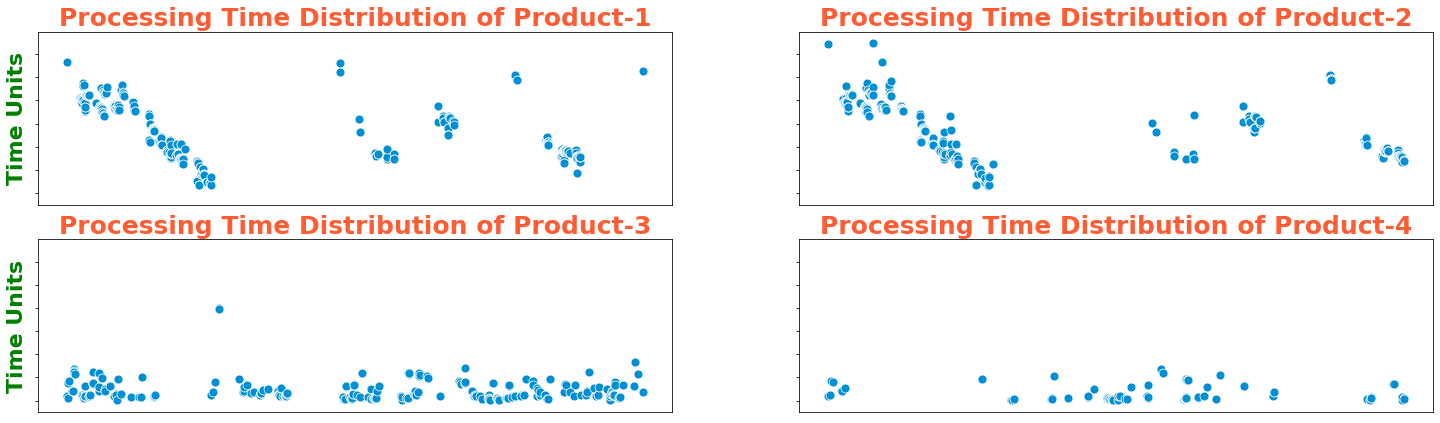

In [22]:
a0=df2["products"].value_counts().index[0]
a1=df2["products"].value_counts().index[1]
a2=df2["products"].value_counts().index[21]
a3=df2["products"].value_counts().index[101]

nrows=2
ncols=2
fig,ax=plt.subplots(nrows=nrows,ncols=ncols,figsize=(25,7),sharey=True)

def lineDetails(temp,i,j,xlabel,ylabel,tittle):
    g=sns.scatterplot(data=temp,y="timetaken",x="min",ax=ax[i,j],s=80,color="#008FD5")
    ax[i,j].set_ylabel(ylabel,fontsize=22,fontweight='bold',color='green')
    ax[i,j].set_title(tittle,fontsize=25,fontweight="bold",color="#ff5c33")
    plt.draw()
    ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(),fontsize=19,fontweight="bold")
    ax[i,j].axes.get_xaxis().set_visible(False)   
    
lineDetails(df2[df2["products"]==a0],0,0,"Lines","Time Units",
            "Processing Time Distribution of Product-1")
lineDetails(df2[df2["products"]==a1],0,1,"Lines","Time Units",
            "Processing Time Distribution of Product-2")
lineDetails(df2[df2["products"]==a2],1,0,"Lines","Time Units",
            "Processing Time Distribution of Product-3")
lineDetails(df2[df2["products"]==a3],1,1,"Lines","Time Units",
            "Processing Time Distribution of Product-4")

In [23]:
df2["products"].value_counts()

0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011111111111111011111110000000000000000000111111111111111111100000000011111111111111111111111000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000111111111111111111111111110000000000000000000000000000000000000000000000000000111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111

### PLOT OF PRODUCTION RATE OVER TIME

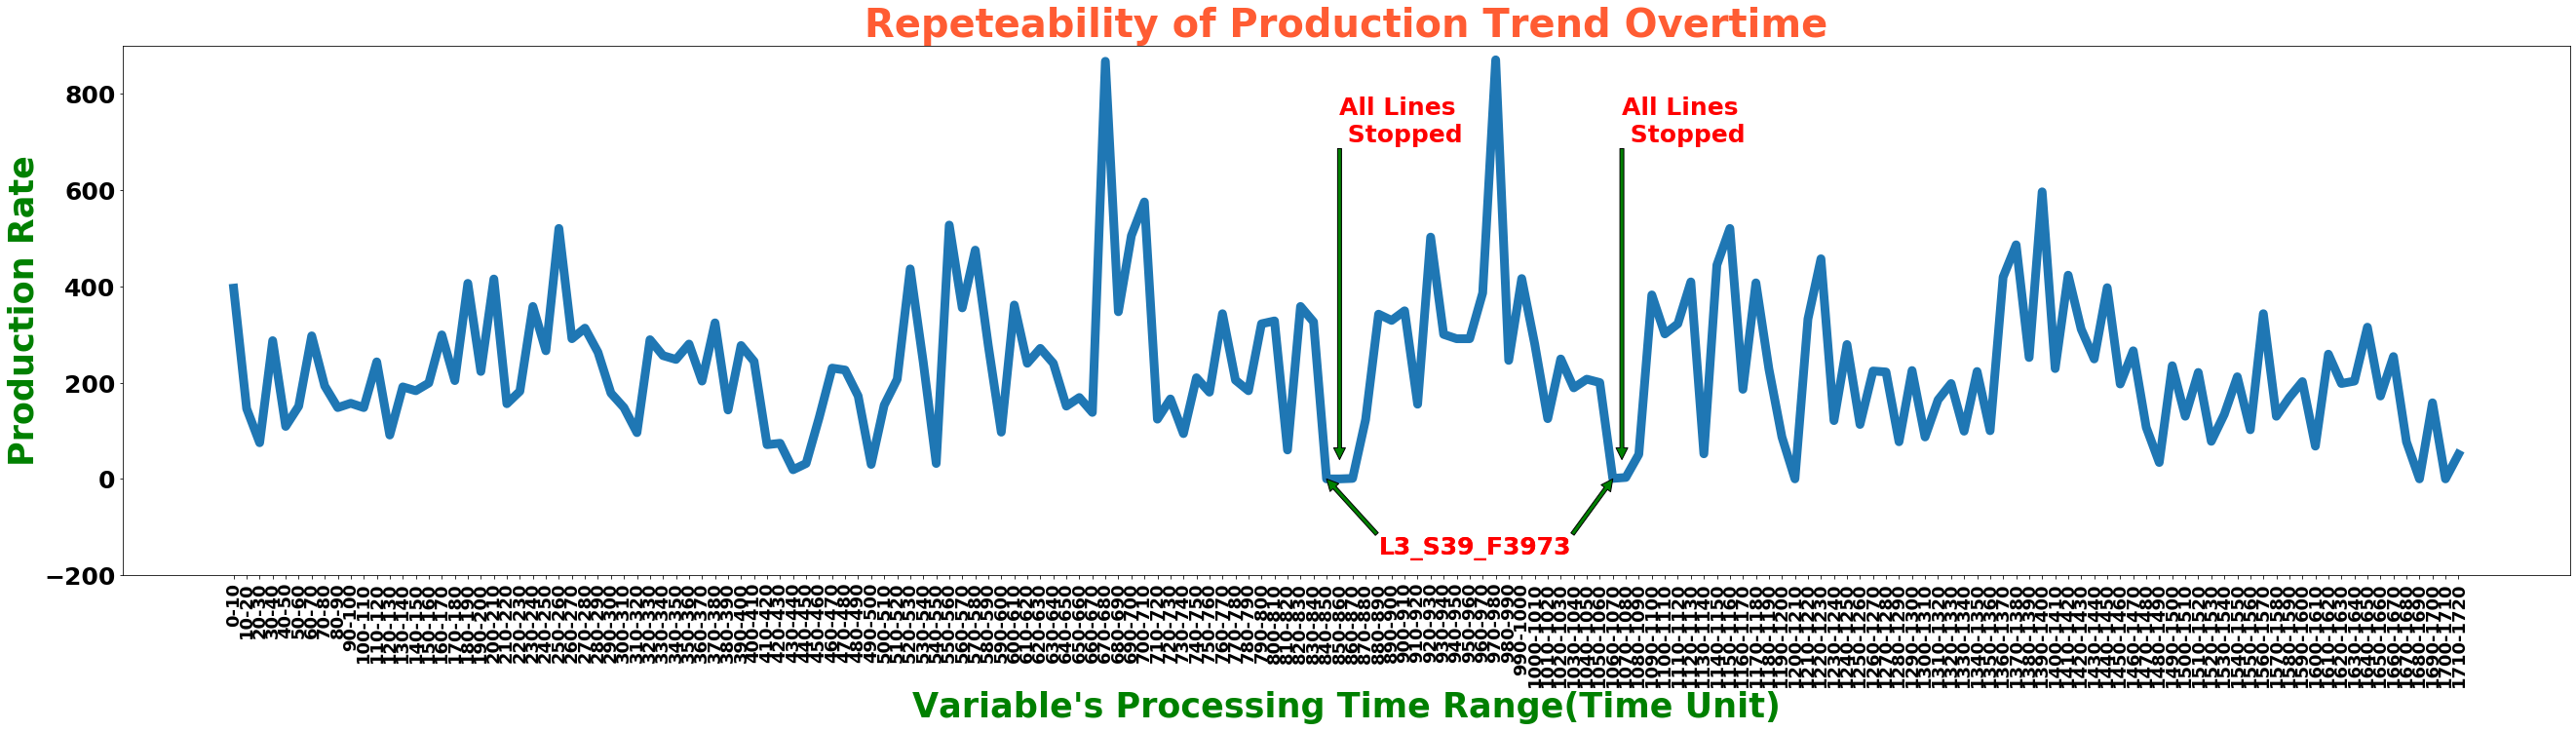

In [24]:
#0-1713.71,
bins=[-np.inf, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 
      160, 170, 
      180, 190, 200,210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 
      350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 
      520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 
      690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 
      860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 
      1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 
      1160, 1170, 1180, 1190, 1200, 1210, 1220, 1230, 1240, 1250, 1260, 1270, 1280, 1290, 
      1300, 1310, 1320, 1330, 1340, 1350, 1360, 1370, 1380, 1390, 1400, 1410, 1420, 1430, 
      1440, 1450, 1460, 1470, 1480, 1490, 1500, 1510, 1520, 1530, 1540, 1550, 1560, 1570, 
      1580, 1590, 1600, 1610, 1620, 1630, 1640, 1650, 1660, 1670, 1680, 1690, 1700, 1710, 
      np.inf]
labels=['0-10',  '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', 
        '90-100', '100-110', '110-120', '120-130', '130-140', '140-150', '150-160', 
        '160-170', '170-180', '180-190', '190-200', '200-210', '210-220', '220-230', 
        '230-240', '240-250', '250-260', '260-270', '270-280', '280-290', '290-300', 
        '300-310', '310-320', '320-330', '330-340', '340-350', '350-360', '360-370', 
        '370-380', '380-390', '390-400', '400-410', '410-420', '420-430', '430-440', 
        '440-450', '450-460', '460-470', '470-480', '480-490', '490-500', '500-510', 
        '510-520', '520-530', '530-540', '540-550', '550-560', '560-570', '570-580', 
        '580-590', '590-600', '600-610', '610-620', '620-630', '630-640', '640-650', 
        '650-660', '660-670', '670-680', '680-690', '690-700', '700-710', '710-720', 
        '720-730', '730-740', '740-750', '750-760', '760-770', '770-780', '780-790', 
        '790-800', '800-810', '810-820', '820-830', '830-840', '840-850', '850-860', 
        '860-870', '870-880', '880-890', '890-900', '900-910', '910-920', '920-930', 
        '930-940', '940-950', '950-960', '960-970', '970-980', '980-990', '990-1000', 
        '1000-1010', '1010-1020', '1020-1030', '1030-1040', '1040-1050', '1050-1060', 
        '1060-1070', '1070-1080', '1080-1090', '1090-1100', '1100-1110', '1110-1120', 
        '1120-1130', '1130-1140', '1140-1150', '1150-1160', '1160-1170', '1170-1180', 
        '1180-1190', '1190-1200', '1200-1210', '1210-1220', '1220-1230', '1230-1240', 
        '1240-1250', '1250-1260', '1260-1270', '1270-1280', '1280-1290', '1290-1300', 
        '1300-1310', '1310-1320', '1320-1330', '1330-1340', '1340-1350', '1350-1360', 
        '1360-1370', '1370-1380', '1380-1390', '1390-1400', '1400-1410', '1410-1420', 
        '1420-1430', '1430-1440', '1440-1450', '1450-1460', '1460-1470', '1470-1480', 
        '1480-1490', '1490-1500', '1500-1510', '1510-1520', '1520-1530', '1530-1540', 
        '1540-1550', '1550-1560', '1560-1570', '1570-1580', '1580-1590', '1590-1600', 
        '1600-1610', '1610-1620', '1620-1630', '1630-1640', '1640-1650', '1650-1660', 
        '1660-1670', '1670-1680', '1680-1690', '1690-1700', '1700-1710', '1710-1720']
df2["bins"]=pd.cut(df2["min"],bins=bins,labels=labels)

plot=sns.lineplot(x=df2["bins"].value_counts().index, 
            y=df2["bins"].value_counts().tolist(), data=df2,linewidth=9)
plt.gcf().set_size_inches(45,10)
plt.xlabel("Variable's Processing Time Range(Time Unit)",fontsize=35,fontweight="bold",color="green")
plt.ylabel("Production Rate",fontsize=35,fontweight="bold",color="green")
plt.xticks(fontsize=18,fontweight="bold",rotation=90)
plt.yticks(fontsize=25,fontweight="bold")
plt.title("Repeteability of Production Trend Overtime",
          fontsize=40,fontweight="bold",color="#ff5c33")

plt.ylim(-200,900)

plt.annotate('All Lines\n Stopped', xy=(85,40),color='red',
             fontsize=25,xytext=(85,700),fontweight="bold",
             arrowprops=dict(facecolor='green', shrink=0.0001))

plt.annotate('All Lines\n Stopped', xy=(106.7,40),color='red',
             fontsize=25,xytext=(106.7,700),fontweight="bold",
             arrowprops=dict(facecolor='green', shrink=0.0001))

plt.annotate('L3_S39_F3973', xy=(84,0),color='red',
             fontsize=25,xytext=(88,-155),fontweight="bold",
             arrowprops=dict(facecolor='green', shrink=0.0001))

plt.annotate('L3_S39_F3973', xy=(106,0),color='red',
             fontsize=25,xytext=(88,-155),fontweight="bold",
             arrowprops=dict(facecolor='green', shrink=0.0001))

plt.show()

temp1=df2[df2["bins"]=="830-840"]
lp1=temp1["products"].tolist()[-1]
temp2=df2[df2["bins"]=="1050-1060"]
lp2=temp2["products"].tolist()[-1]
lp1

lp2

aa="10000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000"
bb="10000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000"

df2.columns.tolist()[-101]

aa==bb